In [16]:
# Feature Engineering

# Feature 1: Total family members traveling together
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Feature 2: Whether passenger was traveling alone
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

print(df[["FamilySize", "IsAlone"]].head())

   FamilySize  IsAlone
0           2        0
2           1        1
3           2        0
4           1        1
5           1        1


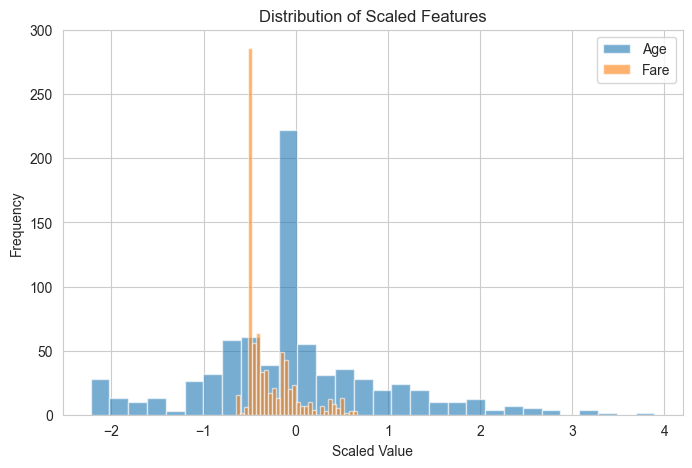

In [14]:
# Visualization 2: Scaled Age and Fare

plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=30, alpha=0.6, label="Age")
plt.hist(df["Fare"], bins=30, alpha=0.6, label="Fare")

plt.title("Distribution of Scaled Features")
plt.xlabel("Scaled Value")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("preprocessing_visualizations/scaled_features.png")

plt.show()

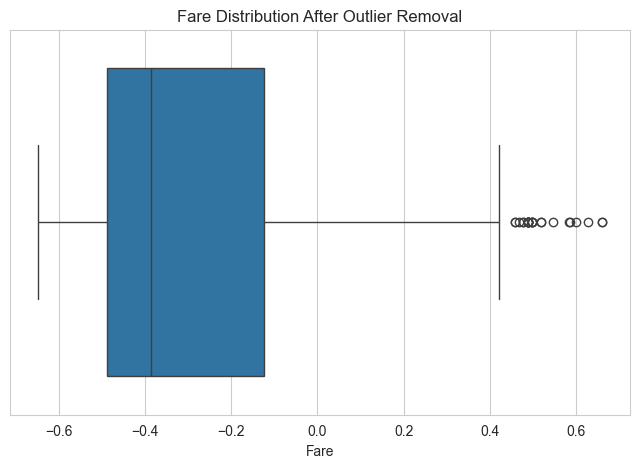

In [13]:
# Visualization 1: Fare distribution after outlier removal

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution After Outlier Removal")

plt.savefig("preprocessing_visualizations/fare_boxplot_after.png")

plt.show()

In [12]:
# Save cleaned dataset

df.to_csv("cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully as cleaned_titanic.csv")

Cleaned dataset saved successfully as cleaned_titanic.csv


In [11]:
# Dataset comparison after preprocessing

print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst Five Rows:")
df.head()

Final Dataset Shape: (775, 12)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

First Five Rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,Unknown,2
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,Unknown,2
5,6,0,3,"Moran, Mr. James",1,-0.104637,0,0,330877,-0.478116,Unknown,1


In [ ]:
# Feature Engineering

# Feature 1: Total family members traveling together
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Feature 2: Whether passenger was traveling alone
df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

print(df[["FamilySize", "IsAlone"]].head())

In [10]:
# Remove outliers using the IQR method

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_rows = df.shape[0]

df = df[(df["Fare"] >= lower_bound) & (df["Fare"] <= upper_bound)]

after_rows = df.shape[0]

print("Rows before removing outliers:", before_rows)
print("Rows after removing outliers :", after_rows)
print("Outliers Removed:", before_rows - after_rows)

Rows before removing outliers: 891
Rows after removing outliers : 775
Outliers Removed: 116


In [9]:
# Normalize numerical features

scaler = StandardScaler()

df[["Age", "Fare"]] = scaler.fit_transform(df[["Age", "Fare"]])

print("Age and Fare have been normalized.")

df.head()

Age and Fare have been normalized.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.663861,1,0,PC 17599,0.786845,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,Unknown,2


In [8]:
# Encode categorical variables

label_encoder = LabelEncoder()

df["Sex"] = label_encoder.fit_transform(df["Sex"])
df["Embarked"] = label_encoder.fit_transform(df["Embarked"])

print("Categorical variables encoded successfully.")

df.head()

Categorical variables encoded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2


In [7]:
# Handle missing values

# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most frequent value (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill missing Cabin values with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

# Verify that missing values are handled
print("Missing Values After Cleaning:\n")
print(df.isnull().sum())

Missing Values After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [6]:
# Check missing values before preprocessing

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Total Missing Values: 866


In [5]:
# Dataset overview before preprocessing

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# Load the dataset

df = pd.read_csv("titanic.csv")

# Display the first five rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_style("whitegrid")

In [2]:
# Week 2: Data Preprocessing & Feature Engineering

### Zynxis AI/ML Internship

##**Intern:** Muhammad Abdullah

##**Dataset:** Titanic Dataset

## Objective

##The objective of this project is to preprocess the Titanic dataset by handling missing values, encoding categorical variables, scaling numerical features, removing outliers, and creating new features to prepare the dataset for machine learning models.

In [1]:
print("Week 2 Started Successfully(testing)")

Week 2 Started Successfully(testing)
